In [338]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from uncertainties import ufloat
from uncertainties.umath import sqrt
from odrpack import odr_fit
from scipy.optimize import curve_fit
from uncertainties import unumpy as unp
%matplotlib inline
plt.ion()

In [339]:
na = pd.read_json("NaLinesFitted.json").T
he = pd.read_json("HeLinesFitted.json").T
hg = pd.read_json("HgLinesFitted.json").T
cd = pd.read_json("CdLinesFitted.json").T
zn = pd.read_json("ZnLinesFitted.json").T
ne = pd.read_json("NeLinesFitted.json").T
he["wavelength"]/=10000
na["wavelength"]/=10000
hg["wavelength"]/=10000
cd["wavelength"]/=10000
zn["wavelength"]/=10000
ne["wavelength"]/=10000
he["place_err"]=0.3
na["place_err"]=0.3
hg["place_err"]=0.3
cd["place_err"]=0.3
zn["place_err"]=0.3
ne["place_err"]=0.3
he["symbol"]="He"
na["symbol"]="Na"
hg["symbol"]="Hg"
cd["symbol"]="Cd"
zn["symbol"]="Zn"
ne["symbol"]="Ne"

In [340]:
all = pd.concat([na,hg,cd,zn,ne], ignore_index=True)
all.head()
all = all.dropna()

In [341]:
def f(x, A, B):
        return A + B/(x**2)

coeff,cov = curve_fit(f,all["wavelength"],all["place"],sigma=all["place_err"],absolute_sigma=True)
print(coeff,cov)
def f3(x,beta):
        A,B=beta
        return A*x+B
sol = odr_fit(f3, all["place"], all["wavelength"]**(-2), [0,0],
              weight_x=all["place_err"])
print(sol.beta,sol.cov_beta)

[-7.56903014  4.12319921] [[ 0.03998193 -0.01107224]
 [-0.01107224  0.00327076]]
[0.22941857 1.91948598] [[ 0.00235675 -0.01505699]
 [-0.01505699  0.1288486 ]]


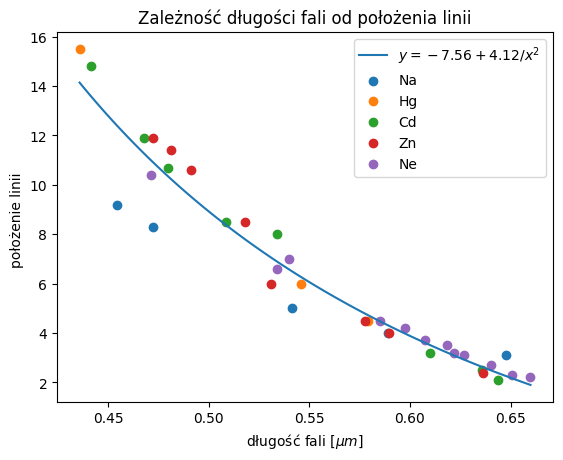

In [342]:
x_fit = np.linspace(min(all["wavelength"]), max(all["wavelength"]), 100)
y_fit = coeff[0]+coeff[1]/ (x_fit**2)

plt.figure()
plt.plot(x_fit, (y_fit),label=r"$y = -7.56 + 4.12 /x^2$")
plt.scatter(all[all["symbol"]=="Na"]["wavelength"],all[all["symbol"]=="Na"]["place"],label="Na")
plt.scatter(all[all["symbol"]=="Hg"]["wavelength"],all[all["symbol"]=="Hg"]["place"],label="Hg")
plt.scatter(all[all["symbol"]=="Cd"]["wavelength"],all[all["symbol"]=="Cd"]["place"],label="Cd")
plt.scatter(all[all["symbol"]=="Zn"]["wavelength"],all[all["symbol"]=="Zn"]["place"],label="Zn")
plt.scatter(all[all["symbol"]=="Ne"]["wavelength"],all[all["symbol"]=="Ne"]["place"],label="Ne")
plt.xlabel(r"długość fali $[\mu m]$")
plt.ylabel("położenie linii ")
plt.title("Zależność długości fali od położenia linii")
plt.legend()
plt.show()

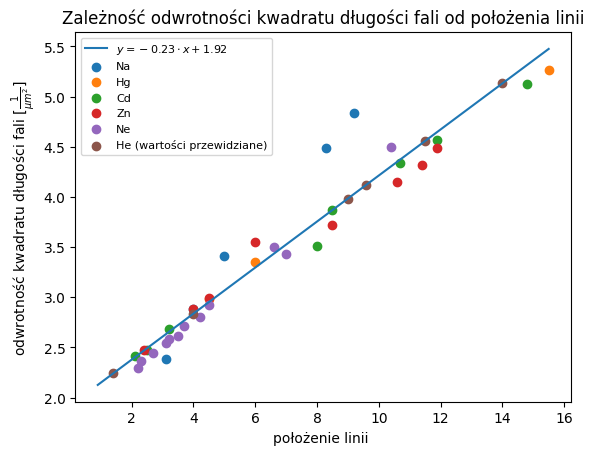

In [343]:
x_fit = np.linspace(min(he["place"]-0.5), max(all["place"]), 100)
y_fit = sol.beta[0]*x_fit+sol.beta[1]

plt.figure()
plt.plot(x_fit, (y_fit),label=r"$y = -0.23\cdot x + 1.92$")
plt.scatter(all[all["symbol"]=="Na"]["place"],all[all["symbol"]=="Na"]["wavelength"]**(-2),label="Na")
plt.scatter(all[all["symbol"]=="Hg"]["place"],all[all["symbol"]=="Hg"]["wavelength"]**(-2),label="Hg")
plt.scatter(all[all["symbol"]=="Cd"]["place"],all[all["symbol"]=="Cd"]["wavelength"]**(-2),label="Cd")
plt.scatter(all[all["symbol"]=="Zn"]["place"],all[all["symbol"]=="Zn"]["wavelength"]**(-2),label="Zn")
plt.scatter(all[all["symbol"]=="Ne"]["place"],all[all["symbol"]=="Ne"]["wavelength"]**(-2),label="Ne")
plt.scatter(he["place"],f3(he["place"],(sol.beta[0],sol.beta[1])),label="He (wartości przewidziane)")
plt.ylabel(r"odwrotność kwadratu długości fali $[\frac{1}{\mu m^2}]$")
plt.xlabel("położenie linii ")
plt.title("Zależność odwrotności kwadratu długości fali od położenia linii")
plt.legend(fontsize=8)
plt.show()

In [344]:
uhe = unp.uarray(he["place"],he["place_err"])
ua = ufloat(sol.beta[0],np.sqrt(sol.cov_beta[0,0]))
ub = ufloat(sol.beta[1],np.sqrt(sol.cov_beta[1,1]))
print(uhe,ua,ub)
print(1/(f3(uhe,(ua,ub))**(0.5)))

[1.4+/-0.3 4.0+/-0.3 9.0+/-0.3 9.6+/-0.3 11.5+/-0.3 14.0+/-0.3] 0.23+/-0.05 1.9+/-0.4
[0.6680529064559457+/-0.05541969288646284
 0.5936877178275906+/-0.04330266737597048
 0.5009870931420792+/-0.03581335052737083
 0.49255082153467883+/-0.0353869089148843
 0.46840593297342953+/-0.03428835117363879
 0.44145287436315045+/-0.03319455295761072]
